In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

# Mission 3 — Modélisation et comparaison des modèles

L'objectif de cette mission est de comparer plusieurs algorithmes de
classification afin d'identifier celui qui prédit le mieux le churn des
clients.

Avant toute comparaison, un modèle de référence très simple (baseline naïve)
sera construit.

Trois familles d'algorithmes seront ensuite étudiées :

- un modèle linéaire : Régression Logistique ;
- un modèle à base d'arbres : Random Forest ;
- un troisième modèle : Support Vector Machine (SVM).

Les performances seront évaluées à l'aide d'une validation croisée
stratifiée à cinq plis en utilisant exactement les mêmes découpages pour tous
les modèles.

Enfin, un test statistique de Wilcoxon permettra de vérifier si la différence
entre les deux meilleurs modèles est réellement significative.

In [2]:
#Importation des bibliotheques
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    make_scorer,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import seaborn as sns

## 3. Chargement des données

Nous chargeons le jeu de données Telco Customer Churn qui sera utilisé pour
la comparaison des différents modèles de classification.

Avant de commencer la modélisation, quelques opérations de préparation sont
réalisées :

- chargement du fichier CSV ;
- conversion de la variable `TotalCharges` en variable numérique ;
- suppression de l'identifiant `customerID`, qui n'apporte aucune information
  prédictive ;
- séparation des variables explicatives (`X`) et de la variable cible (`y`).

In [3]:
# Chargement des données
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Aperçu
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.1 Informations générales

Nous vérifions les dimensions du dataset ainsi que les types des variables
avant de poursuivre la préparation des données.

In [4]:
print("Dimensions :", df.shape)

df.info()

Dimensions : (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

### 3.2 Préparation des variables

La variable `TotalCharges` est convertie en variable numérique.

Les valeurs impossibles à convertir sont remplacées par des valeurs manquantes
(`NaN`), qui seront ensuite traitées automatiquement dans le pipeline.

La variable `customerID` est supprimée car elle correspond uniquement à un
identifiant unique de client et ne possède aucune valeur prédictive.

In [5]:
# Conversion de TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Suppression de l'identifiant
df = df.drop(columns="customerID")

# Variables explicatives
X = df.drop(columns="Churn")

# Variable cible
y = df["Churn"]

print("X :", X.shape)
print("y :", y.shape)

X : (7043, 19)
y : (7043,)


### 3.3 Distribution de la variable cible

Nous vérifions la répartition des classes afin de confirmer le déséquilibre
du problème de classification.

Cette distribution justifie l'utilisation d'une validation croisée
stratifiée ainsi que de métriques adaptées au churn.

In [6]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
y.value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

## 4. Séparation des données

Le dataset est séparé en un ensemble d'entraînement (80 %) et un ensemble de
test (20 %).

La séparation est réalisée de manière **stratifiée** sur la variable cible
`Churn`, afin de conserver les mêmes proportions de clients ayant résilié
et de clients fidèles dans les deux ensembles.

Le jeu d'entraînement sera utilisé pour la validation croisée et
l'apprentissage des modèles, tandis que le jeu de test sera conservé
uniquement pour l'évaluation finale du meilleur modèle.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (5634, 19)
X_test  : (1409, 19)
y_train : (5634,)
y_test  : (1409,)


### 4.1 Vérification de la stratification

Nous vérifions que la proportion de clients ayant churné est conservée
dans les ensembles d'entraînement et de test.

Cette étape garantit que les performances des modèles ne seront pas biaisées
par une répartition différente des classes.

In [9]:
print("Distribution globale (%)")
print(y.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution train (%)")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution test (%)")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Distribution globale (%)
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Distribution train (%)
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Distribution test (%)
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## 5. Construction du pipeline de prétraitement

Afin de garantir une comparaison équitable entre les différents modèles, le
même pipeline de préparation des données est utilisé pour tous les
algorithmes.

Les variables numériques sont imputées par leur médiane puis standardisées.

Les variables catégorielles sont imputées par leur modalité la plus fréquente
puis transformées à l'aide d'un encodage One-Hot.

Toutes ces transformations sont intégrées dans un `ColumnTransformer` puis
réalisées automatiquement à l'intérieur de chaque pipeline de modélisation.

Les paramètres d'imputation, de standardisation et d'encodage sont appris
uniquement sur les données d'entraînement lors de chaque fold de validation
croisée, ce qui évite toute fuite d'information.

### 5.1 Définition des types de variables

Les variables sont séparées en variables numériques et catégorielles.

La variable `SeniorCitizen` est considérée comme catégorielle bien qu'elle
soit codée sous forme numérique, car les valeurs 0 et 1 représentent deux
catégories et non une quantité.

In [10]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col
    for col in X_train.columns
    if col not in numeric_features
]

print("Variables numériques :")
print(numeric_features)

print("\nVariables catégorielles :")
print(categorical_features)

Variables numériques :
['tenure', 'MonthlyCharges', 'TotalCharges']

Variables catégorielles :
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 5.2 Pipeline des variables numériques

Les variables numériques sont préparées selon les étapes suivantes :

- imputation des valeurs manquantes par la médiane ;
- standardisation avec `StandardScaler`.

In [11]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

### 5.3 Pipeline des variables catégorielles

Les variables catégorielles sont préparées selon les étapes suivantes :

- imputation de la modalité la plus fréquente ;
- encodage One-Hot afin de convertir les catégories en variables numériques.

In [12]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

### 5.4 Construction du ColumnTransformer

Les pipelines numérique et catégoriel sont regroupés dans un
`ColumnTransformer`.

Cette structure permet d'appliquer automatiquement le traitement approprié à
chaque type de variable.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 6. Baseline naïve

Avant d'entraîner des modèles de Machine Learning, nous construisons une
baseline naïve.

Cette baseline consiste à prédire systématiquement la classe majoritaire,
c'est-à-dire **"No"** (client qui ne résilie pas).

Cette approche ne nécessite aucun apprentissage et sert de référence minimale.
Les modèles de Machine Learning devront obtenir de meilleures performances,
notamment sur les métriques liées à la détection des clients qui churnent.

### 6.1 Prédictions de la baseline

La baseline attribue la classe **"No"** à tous les clients du jeu de test.

In [14]:
y_pred_baseline = np.repeat(
    "No",
    len(y_test)
)

y_pred_baseline[:10]

array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No'],
      dtype='<U2')

### 6.2 Évaluation de la baseline

Nous calculons les principales métriques de performance de cette baseline :

- Accuracy
- Precision
- Recall
- F1-score

Ces résultats serviront de référence pour comparer les modèles de Machine
Learning.

In [15]:
accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

precision = precision_score(
    y_test,
    y_pred_baseline,
    pos_label="Yes",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_baseline,
    pos_label="Yes",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_baseline,
    pos_label="Yes",
    zero_division=0
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.7346
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000


## 6.3 Rapport de classification

In [16]:
print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          No       0.73      1.00      0.85      1035
         Yes       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



## 6.4 Matrice de confusion

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred_baseline,
    labels=["No", "Yes"]
)

cm

array([[1035,    0],
       [ 374,    0]])

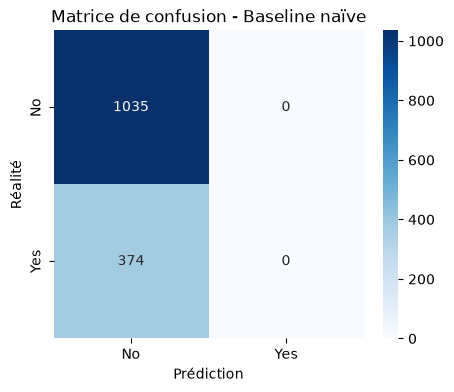

In [18]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion - Baseline naïve")

plt.show()

### 6.5. Interprétation de la baseline

La baseline naïve consiste à prédire systématiquement la classe majoritaire
`No` (client qui ne résilie pas).

Cette stratégie obtient une **accuracy de 73,46 %**, ce qui correspond à la
proportion de clients fidèles dans le dataset. Cependant, cette performance
est trompeuse car le modèle ne détecte **aucun** client susceptible de churner.

Le rappel (**Recall**) et le **F1-score** de la classe `Churn = Yes` sont
tous deux égaux à **0**, ce qui signifie que les **374 clients ayant réellement
résilié** sont tous classés à tort comme des clients fidèles.

La matrice de confusion confirme ce résultat :

- **1035 vrais négatifs** ;
- **374 faux négatifs** ;
- **0 vrai positif** ;
- **0 faux positif**.

Cette baseline constitue une référence minimale. Un modèle de Machine Learning
pertinent devra améliorer significativement le rappel et le F1-score tout en
conservant de bonnes performances globales.

## 7. Régression Logistique

La régression logistique est retenue comme premier modèle de classification.

Il s'agit d'un modèle linéaire largement utilisé pour les problèmes de
classification binaire. Il présente plusieurs avantages :

- simplicité d'interprétation ;
- rapidité d'entraînement ;
- bonne capacité de généralisation ;
- possibilité d'estimer directement une probabilité de churn.

Ce modèle constitue également la baseline de Machine Learning contre laquelle
seront comparés les autres algorithmes.

### 7.1 Construction du pipeline

Le pipeline combine :

- le prétraitement des variables numériques ;
- le prétraitement des variables catégorielles ;
- une régression logistique.

L'ensemble des transformations est réalisé automatiquement à chaque fold de
validation croisée.

In [19]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 7.2 Validation croisée

Les performances de la régression logistique sont évaluées par validation
croisée stratifiée à cinq plis.

Les mêmes découpages seront réutilisés pour les autres modèles afin de
garantir une comparaison équitable.

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",

    "recall": make_scorer(
        recall_score,
        pos_label="Yes"
    ),

    "f1": make_scorer(
        f1_score,
        pos_label="Yes"
    ),

    "roc_auc": "roc_auc"
}

In [21]:
cv_logistic = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


## 7.3 Résultats

In [22]:
logistic_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Moyenne": [
        cv_logistic["test_accuracy"].mean(),
        cv_logistic["test_recall"].mean(),
        cv_logistic["test_f1"].mean(),
        cv_logistic["test_roc_auc"].mean()
    ],

    "Écart-type": [
        cv_logistic["test_accuracy"].std(),
        cv_logistic["test_recall"].std(),
        cv_logistic["test_f1"].std(),
        cv_logistic["test_roc_auc"].std()
    ]
})

logistic_results.round(4)

,Métrique,Moyenne,Écart-type
0,Accuracy,0.8026,0.0120
1,Recall,0.5431,0.0411
2,F1-score,0.5930,0.0298
3,ROC-AUC,0.8461,0.0125


## 7.4 Boxplot des scores

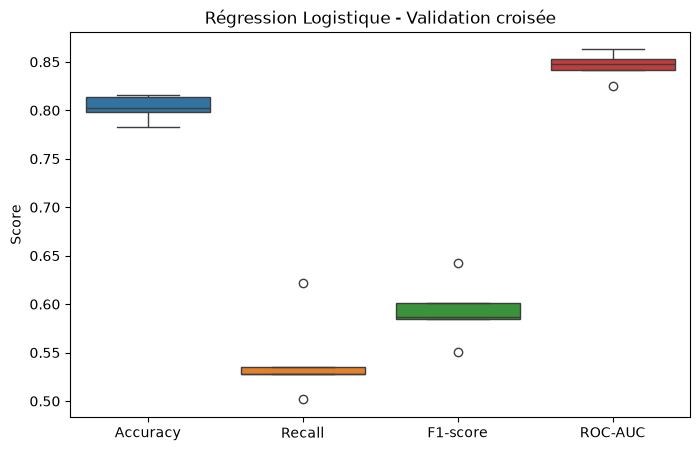

In [23]:
scores_logistic = pd.DataFrame({
    "Accuracy": cv_logistic["test_accuracy"],
    "Recall": cv_logistic["test_recall"],
    "F1-score": cv_logistic["test_f1"],
    "ROC-AUC": cv_logistic["test_roc_auc"]
})

plt.figure(figsize=(8,5))

sns.boxplot(data=scores_logistic)

plt.title("Régression Logistique - Validation croisée")

plt.ylabel("Score")

plt.show()

### 7.5. Interprétation de la validation croisée

La régression logistique présente une bonne stabilité en validation croisée.

Les métriques `Accuracy` (écart-type = 0,0120) et `ROC-AUC` (écart-type = 0,0125)
varient très peu d'un pli à l'autre, ce qui montre que le modèle généralise
correctement sur différents sous-ensembles des données.

Le `Recall` présente une variabilité plus importante (écart-type = 0,0411).
Cette variation est attendue, car la classe `Churn = Yes` est minoritaire et
sa répartition peut légèrement varier selon les plis de validation croisée.

Aucun pli ne présente un comportement anormal ou aberrant. Les résultats
peuvent donc être considérés comme fiables et servir de référence pour la
comparaison avec les autres modèles.

## 8. Random Forest

La forêt aléatoire (Random Forest) est un ensemble de plusieurs arbres de
décision construits sur différents sous-échantillons des données.

Ce modèle est capable de capturer des relations non linéaires entre les
variables et est généralement moins sensible au surapprentissage qu'un arbre
de décision unique.

Contrairement à la régression logistique, Random Forest peut modéliser des
interactions complexes entre les variables sans qu'il soit nécessaire de créer
explicitement de nouvelles features.

### 8.1 Construction du pipeline

Le même pipeline de prétraitement est utilisé.

La seule différence avec le modèle précédent est que la régression
logistique est remplacée par une forêt aléatoire.

In [24]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 8.2 Validation croisée

Le modèle est évalué avec exactement les mêmes plis de validation croisée que
la régression logistique afin de garantir une comparaison équitable.

In [25]:
cv_rf = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

### 8.3 Résultats

In [26]:
rf_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Moyenne": [
        cv_rf["test_accuracy"].mean(),
        cv_rf["test_recall"].mean(),
        cv_rf["test_f1"].mean(),
        cv_rf["test_roc_auc"].mean()
    ],

    "Écart-type": [
        cv_rf["test_accuracy"].std(),
        cv_rf["test_recall"].std(),
        cv_rf["test_f1"].std(),
        cv_rf["test_roc_auc"].std()
    ]
})

rf_results.round(4)

,Métrique,Moyenne,Écart-type
0,Accuracy,0.7854,0.0110
1,Recall,0.4816,0.0272
2,F1-score,0.5434,0.0235
3,ROC-AUC,0.8204,0.0121


### 8.4 Boxplot

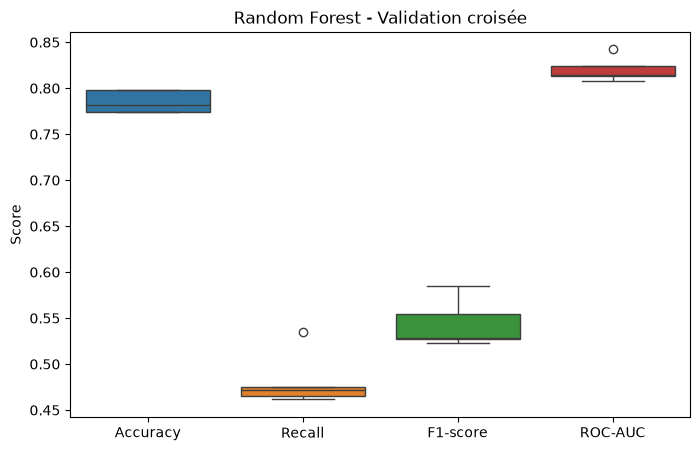

In [27]:
scores_rf = pd.DataFrame({
    "Accuracy": cv_rf["test_accuracy"],
    "Recall": cv_rf["test_recall"],
    "F1-score": cv_rf["test_f1"],
    "ROC-AUC": cv_rf["test_roc_auc"]
})

plt.figure(figsize=(8,5))

sns.boxplot(data=scores_rf)

plt.title("Random Forest - Validation croisée")

plt.ylabel("Score")

plt.show()

### 8.5. Interprétation

La forêt aléatoire obtient des performances inférieures à celles de la
régression logistique sur l'ensemble des métriques étudiées.

L'accuracy moyenne est de **78,54 %**, contre **80,26 %** pour la régression
logistique. Le recall diminue également de **54,31 % à 48,16 %**, ce qui
signifie que la forêt aléatoire détecte moins de clients susceptibles de
résilier.

Le F1-score et le ROC-AUC sont également plus faibles.

Concernant la stabilité, les deux modèles présentent des écarts-types
comparables en validation croisée, ce qui montre des performances relativement
stables d'un pli à l'autre.

Dans cette étude, la régression logistique apparaît donc plus performante que
la forêt aléatoire et constitue, à ce stade, le meilleur modèle.

## 9. Extreme Gradient Boosting (XGBoost)

XGBoost est un algorithme de gradient boosting basé sur des arbres de décision.

Il construit successivement plusieurs arbres, chacun cherchant à corriger les
erreurs du précédent. Cette approche permet généralement d'obtenir des
performances supérieures aux modèles linéaires et aux forêts aléatoires sur
les jeux de données tabulaires.

XGBoost est retenu comme quatrième modèle afin d'évaluer si une méthode de
boosting améliore la prédiction du churn.

## 9.1 Préparation de la cible

Contrairement aux autres modèles, XGBoost attend une cible numérique.

In [28]:
y_train_xgb = (y_train == "Yes").astype(int)

## 9.2 Pipeline

In [29]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("model",
         XGBClassifier(
             n_estimators=300,
             learning_rate=0.05,
             max_depth=4,
             subsample=0.8,
             colsample_bytree=0.8,
             eval_metric="logloss",
             random_state=42
         ))
    ]
)
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 9.3 Validation croisée

Comme la cible est maintenant numérique, il faut adapter le scoring.

In [30]:
from sklearn.metrics import make_scorer

scoring_xgb = {
    "accuracy": "accuracy",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [31]:
cv_xgb = cross_validate(
    xgb_pipeline,
    X_train,
    y_train_xgb,
    cv=cv,
    scoring=scoring_xgb,
    n_jobs=-1
)

### 9.4 Résultats

In [32]:
xgb_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Moyenne": [
        cv_xgb["test_accuracy"].mean(),
        cv_xgb["test_recall"].mean(),
        cv_xgb["test_f1"].mean(),
        cv_xgb["test_roc_auc"].mean()
    ],

    "Écart-type": [
        cv_xgb["test_accuracy"].std(),
        cv_xgb["test_recall"].std(),
        cv_xgb["test_f1"].std(),
        cv_xgb["test_roc_auc"].std()
    ]
})

xgb_results.round(4)

,Métrique,Moyenne,Écart-type
0,Accuracy,0.8017,0.0130
1,Recall,0.5298,0.0285
2,F1-score,0.5864,0.0268
3,ROC-AUC,0.8435,0.0096


### Boxplot XGBoost

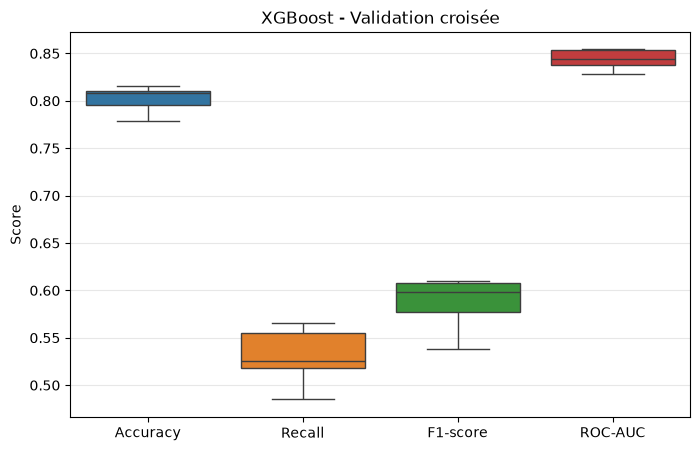

In [33]:
scores_xgb = pd.DataFrame({
    "Accuracy": cv_xgb["test_accuracy"],
    "Recall": cv_xgb["test_recall"],
    "F1-score": cv_xgb["test_f1"],
    "ROC-AUC": cv_xgb["test_roc_auc"]
})

plt.figure(figsize=(8,5))

sns.boxplot(data=scores_xgb)

plt.title("XGBoost - Validation croisée")

plt.ylabel("Score")

plt.grid(axis="y", alpha=0.3)

plt.show()

### 9.6. Interprétation de XGBoost

Le modèle XGBoost obtient de bonnes performances en validation croisée, avec une accuracy moyenne de 80,17 % et un ROC-AUC de 0,8435. Ces résultats montrent une bonne capacité du modèle à distinguer les clients susceptibles de résilier des clients fidèles.

Le recall moyen est de 52,98 %, ce qui signifie que le modèle identifie correctement un peu plus de la moitié des clients qui churnent. Le F1-score atteint 0,5864, traduisant un compromis satisfaisant entre la précision et le rappel.

Le boxplot met en évidence une faible dispersion des scores entre les cinq plis de validation croisée. Les écarts-types sont faibles pour l'ensemble des métriques (0,0130 pour l'accuracy, 0,0285 pour le recall, 0,0268 pour le F1-score et 0,0096 pour le ROC-AUC), ce qui indique que les performances du modèle sont stables et peu sensibles au découpage des données.

En comparaison avec la régression logistique, XGBoost obtient une accuracy très proche (80,17 % contre 80,26 %) ainsi qu'un ROC-AUC comparable (0,8435 contre 0,8461). En revanche, la régression logistique conserve un léger avantage sur le recall (54,31 % contre 52,98 %) et sur le F1-score (0,5930 contre 0,5864).

Ainsi, bien que XGBoost fournisse des performances élevées et une excellente stabilité, la régression logistique demeure légèrement plus performante sur les métriques les plus importantes pour la détection du churn, notamment le rappel des clients susceptibles de résilier.

## 10. Comparaison des modèles

Les trois modèles retenus (Régression Logistique, Random Forest et XGBoost)
sont comparés à partir des résultats obtenus en validation croisée
stratifiée à cinq plis.

Pour chaque modèle, la moyenne et l'écart-type des principales métriques
d'évaluation sont calculés afin d'analyser à la fois les performances et la
stabilité des modèles.

Le modèle retenu devra présenter un bon compromis entre capacité de
prédiction, stabilité et aptitude à détecter les clients susceptibles de
résilier.

In [34]:
comparaison = pd.DataFrame({

    "Rang": [
        1,
        2,
        3
    ],

    "Modèle": [
        "Régression Logistique",
        "XGBoost",
        "Random Forest"
    ],

    "Accuracy (±σ)": [
        f"{cv_logistic['test_accuracy'].mean():.4f} ± {cv_logistic['test_accuracy'].std():.4f}",
        f"{cv_xgb['test_accuracy'].mean():.4f} ± {cv_xgb['test_accuracy'].std():.4f}",
        f"{cv_rf['test_accuracy'].mean():.4f} ± {cv_rf['test_accuracy'].std():.4f}"
    ],

    "Recall (±σ)": [
        f"{cv_logistic['test_recall'].mean():.4f} ± {cv_logistic['test_recall'].std():.4f}",
        f"{cv_xgb['test_recall'].mean():.4f} ± {cv_xgb['test_recall'].std():.4f}",
        f"{cv_rf['test_recall'].mean():.4f} ± {cv_rf['test_recall'].std():.4f}"
    ],

    "F1-score (±σ)": [
        f"{cv_logistic['test_f1'].mean():.4f} ± {cv_logistic['test_f1'].std():.4f}",
        f"{cv_xgb['test_f1'].mean():.4f} ± {cv_xgb['test_f1'].std():.4f}",
        f"{cv_rf['test_f1'].mean():.4f} ± {cv_rf['test_f1'].std():.4f}"
    ],

    "ROC-AUC (±σ)": [
        f"{cv_logistic['test_roc_auc'].mean():.4f} ± {cv_logistic['test_roc_auc'].std():.4f}",
        f"{cv_xgb['test_roc_auc'].mean():.4f} ± {cv_xgb['test_roc_auc'].std():.4f}",
        f"{cv_rf['test_roc_auc'].mean():.4f} ± {cv_rf['test_roc_auc'].std():.4f}"
    ]

})

comparaison

,Rang,Modèle,Accuracy (±σ),Recall (±σ),F1-score (±σ),ROC-AUC (±σ)
0,1,Régression Logistique,0.8026 ± 0.0120,0.5431 ± 0.0411,0.5930 ± 0.0298,0.8461 ± 0.0125
1,2,XGBoost,0.8017 ± 0.0130,0.5298 ± 0.0285,0.5864 ± 0.0268,0.8435 ± 0.0096
2,3,Random Forest,0.7854 ± 0.0110,0.4816 ± 0.0272,0.5434 ± 0.0235,0.8204 ± 0.0121


### 10.1. Interprétation comparative

Les résultats de la validation croisée montrent que la **régression
logistique** est le modèle le plus performant sur ce jeu de données.

Elle obtient le meilleur **recall (54,31 %)**, le meilleur **F1-score
(0,5930)** ainsi que le meilleur **ROC-AUC (0,8461)**. Ces métriques sont
particulièrement importantes dans le contexte de la prédiction du churn, où
l'objectif principal est d'identifier correctement les clients susceptibles
de résilier.

Le modèle **XGBoost** présente des performances très proches de celles de la
régression logistique. Son accuracy atteint **80,17 %** et son ROC-AUC est de
**0,8435**, mais son recall (**52,98 %**) et son F1-score (**0,5864**) restent
légèrement inférieurs.

La **Random Forest** obtient les performances les plus faibles des trois
modèles sur l'ensemble des métriques étudiées.

### 10.2. Analyse de la stabilité

La stabilité des modèles est évaluée à partir des écarts-types obtenus lors de
la validation croisée.

La **Random Forest** présente globalement les plus faibles écarts-types pour
l'accuracy, le recall et le F1-score, ce qui en fait le modèle le plus stable
des trois.

Le modèle **XGBoost** présente le plus faible écart-type pour le ROC-AUC
(0,0096), traduisant une excellente stabilité de sa capacité de
discrimination.

La **régression logistique** affiche des écarts-types légèrement supérieurs,
mais demeure suffisamment stable tout en obtenant les meilleures performances
moyennes.

Ainsi, même si **Random Forest est le modèle le plus stable**, la
**régression logistique** reste le meilleur compromis entre stabilité et
performances prédictives et constitue donc le modèle retenu pour la suite de
l'étude.

## 11. Test statistique de Wilcoxon

Les résultats moyens de la régression logistique et de XGBoost sont très
proches. Afin de déterminer si cette différence est réellement significative
ou simplement due aux variations de la validation croisée, un test non
paramétrique de Wilcoxon est appliqué.

Ce test compare les scores obtenus sur les cinq mêmes plis de validation
croisée.

Les hypothèses sont les suivantes :

- H₀ : les deux modèles présentent des performances équivalentes ;
- H₁ : les performances des deux modèles sont significativement différentes.

Le seuil de significativité retenu est de 5 % (α = 0,05).

### NB:
Le test de Wilcoxon est appliqué aux scores F1 obtenus sur les cinq plis de validation croisée. Le F1-score a été retenu car il constitue une métrique adaptée aux jeux de données déséquilibrés et prend en compte à la fois la précision et le rappel, deux critères importants pour la prédiction du churn.

In [35]:
from scipy.stats import wilcoxon

stat, p_value = wilcoxon(
    cv_logistic["test_f1"],
    cv_xgb["test_f1"]
)

print("Statistique :", stat)
print("p-value :", p_value)

Statistique : 4.0
p-value : 0.4375


### 11.1. Interprétation du test de Wilcoxon

Le test de Wilcoxon a été appliqué afin de comparer les performances de la
régression logistique et de XGBoost à partir des **F1-scores** obtenus sur les
cinq plis de la validation croisée.

Les hypothèses testées sont les suivantes :

- **H₀** : il n'existe pas de différence significative entre les performances
  des deux modèles ;
- **H₁** : les performances des deux modèles sont significativement différentes.

Le test fournit une **statistique de Wilcoxon égale à 4,0** et une
**p-valeur de 0,4375**.

La p-valeur étant **supérieure au seuil de significativité de 5 %**
(p = 0,4375 > 0,05), l'hypothèse nulle **ne peut pas être rejetée**.

Les différences observées entre les performances de la régression logistique
et de XGBoost ne sont donc **pas statistiquement significatives**. Bien que la
régression logistique obtienne des scores moyens légèrement supérieurs,
l'écart observé peut être attribué aux variations naturelles de la validation
croisée.

Par conséquent, les deux modèles présentent des performances comparables d'un
point de vue statistique. La régression logistique est néanmoins retenue comme
modèle final, car elle obtient les meilleures performances moyennes sur les
métriques les plus importantes de cette étude, notamment le **recall**, le
**F1-score** et le **ROC-AUC**, tout en conservant une bonne stabilité.

## 12. Analyse des erreurs

### 12.1 Entraînement final du meilleur modèle

In [36]:
best_model = logistic_pipeline

best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(X_test)
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

### 12.2 Identifier les erreurs

In [37]:
erreurs = X_test.copy()

erreurs["Churn_reel"] = y_test.values
erreurs["Churn_predit"] = y_pred

erreurs["Erreur"] = (
    erreurs["Churn_reel"] != erreurs["Churn_predit"]
)

erreurs.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_reel,Churn_predit,Erreur
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,No,No,False
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,Yes,True
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,No,No,False
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,No,No,False
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No,No,False


### 12.3 Nombre d'erreurs

In [38]:
erreurs["Erreur"].value_counts()

Erreur
False    1135
True      274
Name: count, dtype: int64

### 12.4 Les clients mal classés

In [39]:
clients_mal_classes = erreurs[
    erreurs["Erreur"]
]

clients_mal_classes.shape

(274, 22)

### 12.5 Faux négatifs et faux positifs

In [40]:
faux_negatifs = erreurs[
    (erreurs["Churn_reel"]=="Yes") &
    (erreurs["Churn_predit"]=="No")
]

faux_positifs = erreurs[
    (erreurs["Churn_reel"]=="No") &
    (erreurs["Churn_predit"]=="Yes")
]

print("Faux négatifs :", faux_negatifs.shape[0])
print("Faux positifs :", faux_positifs.shape[0])

Faux négatifs : 165
Faux positifs : 109


### 12.6 Recherche d'un profil

In [41]:
#Contrat
pd.crosstab(
    faux_negatifs["Contract"],
    faux_negatifs["Churn_reel"],
    margins=True
)

Churn_reel,Yes,All
Contract,,
Month-to-month,120,120
One year,36,36
Two year,9,9
All,165,165


In [42]:
#Ancienneté
faux_negatifs["tenure"].describe().round(2)

count    165.00
mean      24.75
std       22.40
min        1.00
25%        3.00
50%       18.00
75%       45.00
max       72.00
Name: tenure, dtype: float64

In [43]:
#Charges mensuelles
faux_negatifs["MonthlyCharges"].describe().round(2)

count    165.00
mean      65.32
std       29.22
min       18.95
25%       45.85
50%       61.45
75%       93.80
max      115.65
Name: MonthlyCharges, dtype: float64

In [44]:
#Service Internet
pd.crosstab(
    faux_negatifs["InternetService"],
    faux_negatifs["Churn_reel"],
    margins=True
)

Churn_reel,Yes,All
InternetService,,
DSL,70,70
Fiber optic,70,70
No,25,25
All,165,165


In [45]:
#Moyen de paiement
pd.crosstab(
    faux_negatifs["PaymentMethod"],
    faux_negatifs["Churn_reel"],
    margins=True
)

Churn_reel,Yes,All
PaymentMethod,,
Bank transfer (automatic),38,38
Credit card (automatic),29,29
Electronic check,54,54
Mailed check,44,44
All,165,165


In [46]:
#SeniorCitizen
pd.crosstab(
    faux_negatifs["SeniorCitizen"],
    faux_negatifs["Churn_reel"],
    margins=True
)

Churn_reel,Yes,All
SeniorCitizen,,
0,132,132
1,33,33
All,165,165


In [47]:
#Partner
pd.crosstab(
    faux_negatifs["Partner"],
    faux_negatifs["Churn_reel"],
    margins=True
)

Churn_reel,Yes,All
Partner,,
No,91,91
Yes,74,74
All,165,165


### 12.6. Analyse des faux négatifs

Les faux négatifs correspondent aux clients ayant réellement résilié leur
abonnement (**Churn = Yes**) mais que le modèle a prédits à tort comme des
clients fidèles (**Churn = No**).

Au total, **165 faux négatifs** sont observés. Dans le contexte métier de cette
étude, ces erreurs sont les plus critiques, car elles représentent des clients
qui risquent de quitter l'entreprise sans être détectés.

L'analyse met en évidence plusieurs caractéristiques communes :

- **Type de contrat** : la majorité des faux négatifs (**120 sur 165**, soit
  près de 73 %) possède un contrat **Month-to-month**. Les contrats annuels
  (36) et de deux ans (9) sont beaucoup moins représentés.

- **Ancienneté** : les clients mal classés présentent une ancienneté moyenne de
  **24,75 mois**, avec une médiane de **18 mois**. Le premier quartile est de
  seulement **3 mois**, ce qui indique que de nombreux clients récemment acquis
  ne sont pas correctement identifiés.

- **Charges mensuelles** : la dépense mensuelle moyenne est de **65,32 $**, avec
  une forte dispersion (écart-type de **29,22 $**). Les faux négatifs concernent
  aussi bien des clients à faible qu'à forte facture mensuelle.

- **Service Internet** : les erreurs sont réparties de manière équilibrée entre
  les abonnés **DSL** (70) et **Fiber optic** (70), tandis que **25 clients**
  ne disposent pas d'un service Internet.

- **Mode de paiement** : les faux négatifs utilisent plus fréquemment
  **Electronic check** (54 clients), suivi de **Mailed check** (44 clients),
  puis des paiements automatiques.

- **SeniorCitizen** : la majorité des faux négatifs (**132 sur 165**) ne sont
  pas des seniors.

- **Partner** : les erreurs sont relativement équilibrées entre les clients
  ayant un partenaire (74) et ceux n'en ayant pas (91), ce qui ne met pas en
  évidence un profil particulier selon cette variable.

Dans l'ensemble, le modèle rencontre principalement des difficultés à détecter
certains clients en **contrat mensuel**, souvent avec une **ancienneté faible à
moyenne**. Ces observations suggèrent que les interactions entre le type de
contrat, l'ancienneté et le mode de paiement pourraient être davantage
exploitées lors du feature engineering afin d'améliorer la détection du churn.

### 12.7 Analyse des faux positifs

In [48]:
#1. Type de contrat
pd.crosstab(
    faux_positifs["Contract"],
    faux_positifs["Churn_reel"],
    margins=True
)

Churn_reel,No,All
Contract,,
Month-to-month,109,109
All,109,109


In [49]:
#2. Ancienneté
faux_positifs["tenure"].describe().round(2)

count    109.00
mean      12.83
std       11.22
min        1.00
25%        4.00
50%        8.00
75%       21.00
max       46.00
Name: tenure, dtype: float64

In [50]:
#3. Charges mensuelles
faux_positifs["MonthlyCharges"].describe().round(2)

count    109.00
mean      80.51
std       15.68
min       24.90
25%       73.85
50%       80.00
75%       90.70
max      111.40
Name: MonthlyCharges, dtype: float64

In [51]:
#4. Service Internet
pd.crosstab(
    faux_positifs["InternetService"],
    faux_positifs["Churn_reel"],
    margins=True
)

Churn_reel,No,All
InternetService,,
DSL,11,11
Fiber optic,98,98
All,109,109


In [52]:
#5. Moyen de paiement
pd.crosstab(
    faux_positifs["PaymentMethod"],
    faux_positifs["Churn_reel"],
    margins=True
)

Churn_reel,No,All
PaymentMethod,,
Bank transfer (automatic),8,8
Credit card (automatic),10,10
Electronic check,76,76
Mailed check,15,15
All,109,109


In [53]:
#6. SeniorCitizen
pd.crosstab(
    faux_positifs["SeniorCitizen"],
    faux_positifs["Churn_reel"],
    margins=True
)

Churn_reel,No,All
SeniorCitizen,,
0,80,80
1,29,29
All,109,109


In [54]:
#7. Partner
pd.crosstab(
    faux_positifs["Partner"],
    faux_positifs["Churn_reel"],
    margins=True
)

Churn_reel,No,All
Partner,,
No,82,82
Yes,27,27
All,109,109


### 12.8. Analyse des faux positifs

Les faux positifs correspondent aux clients n'ayant pas résilié leur
abonnement (**Churn = No**) mais que le modèle prédit à tort comme des clients
susceptibles de résilier (**Churn = Yes**).

Au total, **109 faux positifs** sont observés.

L'analyse met en évidence les caractéristiques suivantes :

- **Type de contrat** : l'ensemble des faux positifs (**109 sur 109**) possède
  un contrat **Month-to-month**. Aucun client disposant d'un contrat annuel ou
  de deux ans n'est concerné.

- **Ancienneté** : ces clients présentent une ancienneté moyenne de
  **12,83 mois**, avec une médiane de **8 mois**, ce qui montre qu'il s'agit
  principalement de clients relativement récents.

- **Charges mensuelles** : la facture mensuelle moyenne est de **80,51 $**,
  supérieure à celle observée pour les faux négatifs. La majorité de ces
  clients présente donc des charges mensuelles relativement élevées.

- **Service Internet** : la quasi-totalité des faux positifs (**98 sur 109**)
  utilise la **fibre optique**, contre seulement **11** abonnés DSL.

- **Mode de paiement** : la majorité des faux positifs (**76 clients**) utilise
  le paiement par **Electronic check**, devant les autres moyens de paiement.

- **SeniorCitizen** : la majorité des faux positifs (**80 sur 109**) ne sont
  pas des seniors.

- **Partner** : les clients sans partenaire sont davantage représentés
  (**82 sur 109**) que ceux vivant en couple.

Ces résultats montrent que le modèle considère certains profils comme étant à
fort risque de résiliation alors qu'ils restent finalement fidèles à
l'entreprise.

### 12.9. Conclusion générale de l'analyse des erreurs

L'analyse des erreurs met en évidence que les difficultés de la régression
logistique concernent principalement des clients présentant des profils
intermédiaires, dont le comportement est plus difficile à distinguer.

Les faux négatifs concernent majoritairement des clients en contrat
**Month-to-month**, avec une ancienneté relativement faible à moyenne et des
modes de paiement principalement basés sur **Electronic check** ou
**Mailed check**.

Les faux positifs présentent également un contrat **Month-to-month**, mais se
caractérisent par une ancienneté encore plus faible, des **charges mensuelles
élevées** et une utilisation très fréquente de la **fibre optique**.

Ces observations montrent que certains clients possèdent des caractéristiques
habituellement associées au churn, sans pour autant résilier leur abonnement.
À l'inverse, d'autres clients résilient malgré un profil relativement proche
de celui des clients fidèles.

Ces résultats suggèrent que les interactions entre les variables jouent un rôle
important dans la décision de résiliation et que certaines relations ne sont
pas entièrement capturées par la régression logistique.

### 12.10. Nouvelles features suggérées

L'analyse des erreurs permet d'identifier plusieurs pistes d'amélioration pour
de futurs travaux de feature engineering.

Parmi les variables susceptibles d'améliorer la détection du churn figurent :

- une interaction entre le **type de contrat** et **l'ancienneté** afin de
  mieux caractériser les nouveaux clients en contrat mensuel ;

- une interaction entre le **service Internet (Fiber optic)** et les
  **charges mensuelles**, les clients utilisant la fibre avec des factures
  élevées étant fréquemment mal classés ;

- une variable regroupant les **modes de paiement automatiques** et les
  **paiements manuels**, afin de simplifier l'information portée par
  `PaymentMethod` ;

- des interactions entre plusieurs variables (contrat, ancienneté, service
  Internet et mode de paiement) qui pourraient être mieux exploitées par des
  modèles non linéaires ou par un feature engineering plus avancé.

Ces pistes constituent des perspectives d'amélioration pour de futures versions
du modèle.

# Mission 4 — Optimisation, calibration et interprétabilité

# 13. Optimisation, calibration et interprétabilité

## 13.1 Optimisation des hyperparamètres avec Optuna

La régression logistique a été retenue comme meilleur modèle à l'issue de la
Mission 3. Cette étape consiste à optimiser automatiquement ses
hyperparamètres afin d'améliorer ses performances.

L'optimisation est réalisée avec **Optuna**, une bibliothèque spécialisée dans
la recherche efficace d'hyperparamètres. Contrairement à une recherche
exhaustive (Grid Search), Optuna explore intelligemment l'espace de recherche
et peut interrompre les essais peu prometteurs grâce à un **pruner**, ce qui
réduit le temps de calcul.

L'objectif est de comparer les performances du modèle optimisé avec celles du
modèle utilisant les paramètres par défaut.

In [55]:
import optuna

print(optuna.__version__)

4.9.0


In [56]:
#import
import optuna

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

from optuna.pruners import MedianPruner

### 13.2 Définition de la fonction objectif

La fonction objectif est utilisée par Optuna pour évaluer chaque combinaison
d'hyperparamètres.

À chaque essai, Optuna :

- sélectionne une combinaison d'hyperparamètres ;
- construit un pipeline complet de prétraitement et de classification ;
- réalise une validation croisée stratifiée ;
- calcule le F1-score moyen.

L'objectif est de maximiser le F1-score moyen obtenu sur les différents plis de
validation croisée.

In [57]:
from sklearn.metrics import make_scorer, f1_score

f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

In [58]:
def objective(trial):

    # -----------------------------
    # Hyperparamètres
    # -----------------------------

    solver = trial.suggest_categorical(
        "solver",
        ["lbfgs", "liblinear", "saga"]
    )

    penalty = trial.suggest_categorical(
        "penalty",
        ["l2", "l1", "elasticnet"]
    )

    # Combinaisons incompatibles
    if penalty == "l1" and solver not in ["liblinear", "saga"]:
        raise optuna.TrialPruned()

    if penalty == "elasticnet" and solver != "saga":
        raise optuna.TrialPruned()

    C = trial.suggest_float(
        "C",
        1e-3,
        100,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    fit_intercept = trial.suggest_categorical(
        "fit_intercept",
        [True, False]
    )

    tol = trial.suggest_float(
        "tol",
        1e-5,
        1e-2,
        log=True
    )

    max_iter = trial.suggest_int(
        "max_iter",
        200,
        2000
    )

    params = dict(
        C=C,
        solver=solver,
        penalty=penalty,
        class_weight=class_weight,
        fit_intercept=fit_intercept,
        tol=tol,
        max_iter=max_iter,
        random_state=42
    )

    # uniquement pour elasticnet
    if penalty == "elasticnet":

        params["l1_ratio"] = trial.suggest_float(
            "l1_ratio",
            0,
            1
        )

    model = LogisticRegression(
        **params
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=f1_scorer,
    n_jobs=-1
)

    return scores.mean()

### 13.3 Recherche des meilleurs hyperparamètres

Une étude Optuna est créée afin d'explorer automatiquement l'espace des
hyperparamètres défini précédemment.

Un **MedianPruner** est utilisé afin d'interrompre les essais peu prometteurs,
ce qui permet de réduire le temps de calcul tout en conservant les essais les
plus performants.

Conformément aux recommandations de l'énoncé, **50 essais** sont réalisés.

In [76]:
#Création de l'étude
"""study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(),
    study_name="LogisticRegression_Optuna"
)"""
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(),
    study_name="LogisticRegression_Optuna"
)

[I 2026-08-04 18:48:09,332] A new study created in memory with name: LogisticRegression_Optuna


In [77]:
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-04 18:48:16,999] Trial 0 finished with value: 0.510952586021469 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.0019517224641449498, 'class_weight': None, 'fit_intercept': True, 'tol': 0.008123245085588688, 'max_iter': 1699}. Best is trial 0 with value: 0.510952586021469.
[I 2026-08-04 18:48:17,007] Trial 1 pruned. 
[I 2026-08-04 18:48:17,011] Trial 2 pruned. 
[I 2026-08-04 18:48:17,017] Trial 3 pruned. 
[I 2026-08-04 18:48:23,022] Trial 4 finished with value: 0.5545441898305972 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 0.0030786517836196197, 'class_weight': None, 'fit_intercept': False, 'tol': 1.2681352169084594e-05, 'max_iter': 1837}. Best is trial 4 with value: 0.5545441898305972.
[I 2026-08-04 18:48:23,579] Trial 5 finished with value: 0.6285945310760174 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 70.45683638454501, 'class_weight': 'balanced', 'fit_intercept': True, 'tol': 0.00582938454299474, 'max_iter': 359}. Best is tri

### 13.4 Résultats de l'optimisation

In [78]:
#Meilleur score
print("Meilleur F1-score :", round(study.best_value, 4))

Meilleur F1-score : 0.631


In [79]:
#Meilleurs hyperparamètres
print("Meilleurs hyperparamètres :\n")

for k, v in study.best_params.items():
    print(f"{k} : {v}")

Meilleurs hyperparamètres :

solver : saga
penalty : elasticnet
C : 0.1813191635347958
class_weight : balanced
fit_intercept : False
tol : 0.0005015471156699764
max_iter : 1284
l1_ratio : 0.9121791321244991


In [80]:
#Tableau récapitulatif
best_params = pd.DataFrame(
    study.best_params.items(),
    columns=["Hyperparamètre", "Valeur optimale"]
)

best_params

,Hyperparamètre,Valeur optimale
0,solver,saga
1,penalty,elasticnet
2,C,0.181319
3,class_weight,balanced
4,fit_intercept,False
5,tol,0.000502
6,max_iter,1284
7,l1_ratio,0.912179


### 13.5 Comparaison avec le modèle par défaut

Les meilleurs hyperparamètres obtenus par Optuna sont comparés aux paramètres
par défaut de la régression logistique afin d'évaluer le gain réel apporté par
l'optimisation.

In [81]:
#Comparaison
gain = pd.DataFrame({

    "Modèle": [
        "Paramètres par défaut",
        "Paramètres optimisés"
    ],

    "F1-score": [
        cv_logistic["test_f1"].mean(),
        study.best_value
    ]

})

gain["Gain"] = gain["F1-score"] - gain["F1-score"].iloc[0]

gain.round(4)

,Modèle,F1-score,Gain
0,Paramètres par défaut,0.593,0.000
1,Paramètres optimisés,0.631,0.038


### 13.5. Interprétation des résultats de l'optimisation

L'optimisation des hyperparamètres de la régression logistique a été réalisée
avec **Optuna** en utilisant une validation croisée stratifiée à cinq plis et
le **F1-score** comme métrique d'optimisation.

Après **50 essais**, Optuna identifie les hyperparamètres suivants comme étant
les plus performants :

| Hyperparamètre | Valeur optimale |
|----------------|-----------------|
| Solver | saga |
| Penalty | elasticnet |
| C | 0,1813 |
| Class weight | balanced |
| Fit intercept | False |
| Tol | 0,000502 |
| Max iter | 1284 |
| l1_ratio | 0,9122 |

Le modèle optimisé obtient un **F1-score moyen de 0,6310**, contre **0,5930**
pour le modèle utilisant les paramètres par défaut.

L'optimisation permet ainsi un **gain absolu de 0,0380**, soit une amélioration
relative d'environ **6,4 %** du F1-score.

Cette amélioration s'explique principalement par plusieurs hyperparamètres :

- **class_weight = balanced**, qui compense le déséquilibre entre les classes
  *Churn = No* et *Churn = Yes* et améliore la détection des clients
  susceptibles de résilier ;

- **penalty = elasticnet** associé au **solver = saga**, qui combine les
  avantages des régularisations L1 et L2 afin de limiter le surapprentissage
  tout en réalisant une sélection des variables les plus pertinentes ;

- **l1_ratio = 0,9122**, qui indique que la régularisation est
  majoritairement de type L1, avec une faible composante L2. Cette combinaison
  permet d'améliorer la généralisation du modèle.

Les autres hyperparamètres (`C`, `tol`, `max_iter` et `fit_intercept`)
contribuent principalement à assurer une convergence stable de l'algorithme et
à affiner les performances du modèle.

Ces résultats montrent que l'optimisation automatique des hyperparamètres
permet d'obtenir un modèle plus performant que celui utilisant les paramètres
par défaut, tout en conservant une bonne capacité de généralisation.

### 13.6 Importance des hyperparamètres

Après l'optimisation, Optuna permet d'estimer l'influence de chaque
hyperparamètre sur les performances du modèle.

Cette analyse identifie les paramètres ayant le plus d'impact sur le
F1-score et permet de mieux comprendre les facteurs qui contribuent à
l'amélioration des performances de la régression logistique.

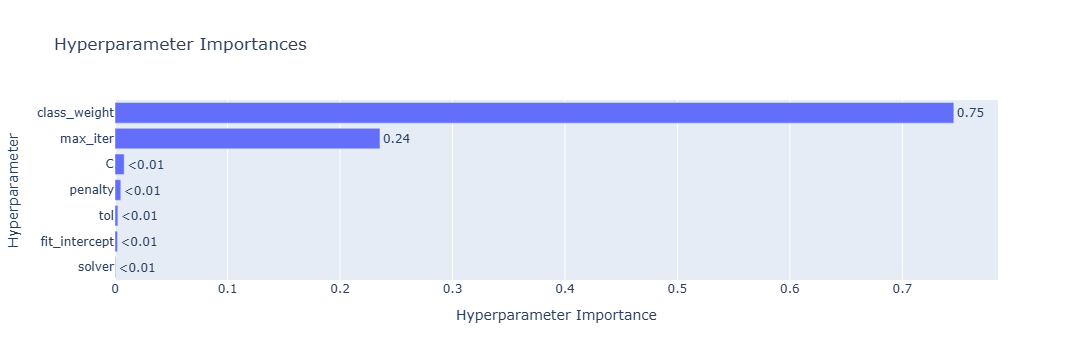

In [82]:
from optuna.visualization import plot_param_importances

fig = plot_param_importances(study)

fig.show()

### 13.6. Interprétation de l'importance des hyperparamètres

L'analyse de l'importance des hyperparamètres montre que **`class_weight`** est
le paramètre ayant le plus d'influence sur les performances de la régression
logistique, avec une importance estimée à **0,75**. Ce résultat s'explique par
le déséquilibre du jeu de données, dans lequel les clients ayant résilié
représentent une minorité. L'utilisation de
**`class_weight="balanced"`** permet de donner davantage de poids à cette
classe lors de l'apprentissage, ce qui améliore la détection des clients
susceptibles de résilier leur abonnement.

Le second hyperparamètre le plus influent est **`max_iter`**, avec une
importance d'environ **0,24**. Ce paramètre contrôle le nombre maximal
d'itérations autorisées pour l'optimisation. Une valeur suffisamment élevée
favorise une meilleure convergence de l'algorithme et contribue ainsi à
améliorer les performances du modèle.

Les autres hyperparamètres (**`C`**, **`penalty`**, **`solver`**,
**`tol`** et **`fit_intercept`**) présentent une importance très faible
(inférieure à **0,01**). Dans l'espace de recherche exploré, leurs variations
n'ont apporté que des améliorations marginales du F1-score.

Ces résultats montrent que la prise en compte du déséquilibre des classes est
le principal facteur d'amélioration des performances, tandis que le nombre
d'itérations joue également un rôle important pour garantir une convergence
optimale de la régression logistique.

# 14. Calibration des probabilités

## 14.1 Principe de la calibration

Les modèles de classification ne produisent pas uniquement une prédiction
(`Churn = Yes` ou `Churn = No`), mais également une **probabilité** associée à
chaque prédiction.

Cependant, ces probabilités ne sont pas toujours parfaitement représentatives
du risque réel. Par exemple, un modèle peut attribuer une probabilité de 80 %
à un groupe de clients alors que seulement 60 % d'entre eux résilient
effectivement leur abonnement.

La **calibration** consiste à ajuster ces probabilités afin qu'elles reflètent
plus fidèlement les probabilités observées dans les données.

Dans cette mission, la qualité de la calibration sera évaluée à l'aide d'un
**Reliability Diagram**, puis améliorée avec **CalibratedClassifierCV** en
utilisant la méthode de **Platt (sigmoid)**. Les performances avant et après
calibration seront ensuite comparées.

### 14.2 Construction du modèle optimisé

Nous utilisons directement les meilleurs hyperparamètres trouvés par Optuna afin d'obtenir le modèle qui sera calibré.

In [83]:
best_model = LogisticRegression(
    **study.best_params,
    random_state=42
)

optimized_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

optimized_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

### 14.3 Vérification des classes

Avant de calculer les probabilités, vérifions que la classe positive est bien "Yes".

In [84]:
optimized_pipeline.named_steps["model"].classes_

array(['No', 'Yes'], dtype=object)

### 14.4 Calcul des probabilités de churn

In [85]:
y_proba = optimized_pipeline.predict_proba(
    X_test
)[:,1]

### 14.5 Reliability Diagram (avant calibration)

In [86]:
from sklearn.calibration import calibration_curve
#Calcul de la courbe
prob_true, prob_pred = calibration_curve(
    y_test.map({"No":0, "Yes":1}),
    y_proba,
    n_bins=10
)

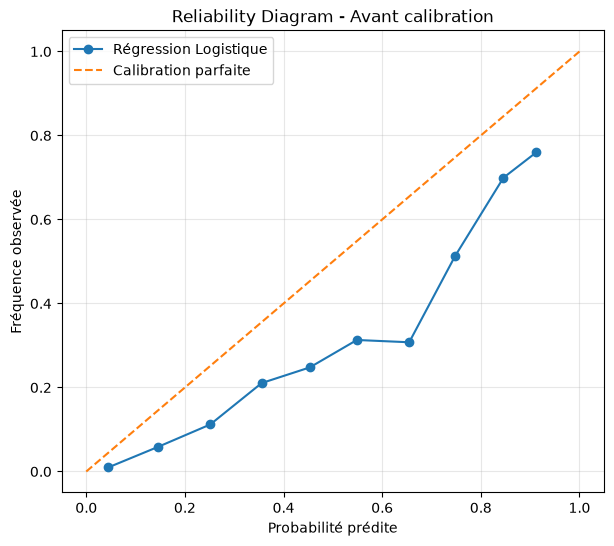

In [87]:
#Tracé le graphique
plt.figure(figsize=(7,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Régression Logistique"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Calibration parfaite"
)

plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence observée")
plt.title("Reliability Diagram - Avant calibration")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### 14.6. Interprétation du Reliability Diagram avant calibration

Le *Reliability Diagram* compare les probabilités prédites par le modèle aux
fréquences réellement observées.

Dans un modèle parfaitement calibré, les points devraient se situer sur la
diagonale représentant une calibration idéale.

Dans notre cas, la courbe est majoritairement située **en dessous de la
diagonale**, ce qui indique que la régression logistique **surestime les
probabilités de churn**. Par exemple, lorsque le modèle prédit une probabilité
de churn proche de 90 %, la fréquence réellement observée est inférieure.

Le modèle présente donc une **calibration imparfaite** : les probabilités
prédites sont globalement plus élevées que les probabilités réellement
observées. Une étape de calibration est donc nécessaire afin d'obtenir des
estimations plus fiables du risque de résiliation.

## 14.7 Calibration des probabilités

Afin d'améliorer la qualité des probabilités prédites, une calibration est
réalisée à l'aide de **CalibratedClassifierCV**.

La méthode retenue est la **méthode de Platt (sigmoid)**, qui ajuste les
probabilités produites par le classifieur à l'aide d'une régression
logistique. Cette méthode est particulièrement adaptée lorsque le nombre
d'observations est modéré et qu'une calibration robuste est recherchée.

In [88]:
#Calibration
from sklearn.calibration import CalibratedClassifierCV

In [89]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=optimized_pipeline,
    method="sigmoid",
    cv=5
)

calibrated_pipeline.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...1156699764))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00235E4584950>, <sk

In [90]:
#Calcul des nouvelles probabilités
y_proba_cal = calibrated_pipeline.predict_proba(
    X_test
)[:,1]

In [91]:
#Nouveau Reliability Diagram
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test.map({"No":0, "Yes":1}),
    y_proba_cal,
    n_bins=10
)

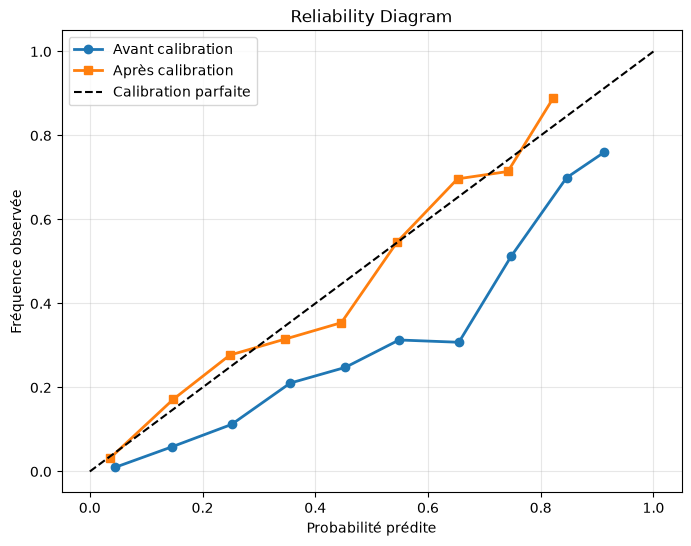

In [92]:
#Tracé comparatif
plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label="Avant calibration"
)

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="s",
    linewidth=2,
    label="Après calibration"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    label="Calibration parfaite"
)

plt.xlabel("Probabilité prédite")

plt.ylabel("Fréquence observée")

plt.title("Reliability Diagram")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### 14.8. Interprétation des résultats de la calibration

Le graphique compare les probabilités prédites par la régression logistique
avant et après l'application de la calibration de Platt (*sigmoid*).

Avant calibration, la courbe est globalement située **en dessous de la
diagonale**, ce qui montre que le modèle **surestime le risque de churn**. Les
probabilités prédites sont donc généralement plus élevées que les fréquences
réellement observées.

Après calibration, la courbe se rapproche nettement de la diagonale de
référence. Les probabilités estimées correspondent davantage aux fréquences
observées, ce qui traduit une **amélioration de la calibration du modèle**.
Même si de légers écarts subsistent pour certaines plages de probabilités, la
courbe calibrée suit beaucoup mieux la tendance idéale que celle obtenue avant
calibration.

La méthode de **Platt (sigmoid)** permet ainsi de produire des probabilités de
churn plus fiables sans modifier le principe de fonctionnement de la régression
logistique. Cette amélioration est particulièrement importante dans un contexte
de fidélisation des clients, où les décisions sont souvent prises à partir des
probabilités estimées plutôt que d'une simple prédiction binaire (« Yes » ou
« No »).

# 15. Interprétabilité avec SHAP

## 15.1 Principe de SHAP

L'amélioration des performances d'un modèle ne suffit pas à expliquer les
raisons qui conduisent à une prédiction. Dans un contexte métier, il est
également important de comprendre pourquoi un client est prédit comme étant
susceptible ou non de résilier son abonnement.

Pour répondre à ce besoin, nous utilisons **SHAP (SHapley Additive
exPlanations)**, une méthode d'interprétabilité fondée sur les valeurs de
Shapley issues de la théorie des jeux.

SHAP mesure la contribution de chaque variable à la prédiction du modèle, aussi
bien de manière globale que pour une observation individuelle. Cette approche
permet d'identifier les variables les plus influentes dans la prédiction du
churn et d'expliquer les décisions prises par le modèle de façon
compréhensible.

In [94]:
#verification
import shap

print(shap.__version__)

0.52.0


## 15.2 Préparation des données

Les explications SHAP sont calculées à partir des variables utilisées par le
modèle après le prétraitement.

Les variables numériques sont imputées et standardisées, tandis que les
variables catégorielles sont imputées puis encodées par **One-Hot Encoding**.
Le jeu de données est donc transformé à l'aide du même préprocesseur que celui
utilisé lors de l'entraînement du modèle optimisé.

Les noms des variables transformées sont également récupérés afin de faciliter
l'interprétation des résultats et des graphiques SHAP.

In [100]:
# Transformation des données avec le préprocesseur
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Récupération des noms des variables après transformation
feature_names = preprocessor.get_feature_names_out()

X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

print("Dimensions du jeu d'entraînement :", X_train_transformed.shape)
print("Dimensions du jeu de test :", X_test_transformed.shape)
print("Nombre de variables :", len(feature_names))

Dimensions du jeu d'entraînement : (5634, 46)
Dimensions du jeu de test : (1409, 46)
Nombre de variables : 46


## 15.3 Création de l'explainer SHAP

Une fois les données prétraitées, un **LinearExplainer** est créé afin de
calculer les valeurs SHAP de la régression logistique optimisée.

Le **LinearExplainer** est particulièrement adapté aux modèles linéaires. Il
attribue à chaque variable une contribution positive ou négative à la
prédiction finale du modèle pour chaque observation.

In [101]:
import shap
explainer = shap.LinearExplainer(
    optimized_pipeline.named_steps["model"],
    X_train_shap
)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


In [102]:
#Calcul des valeurs SHAP
shap_values = explainer(X_test_shap)

In [103]:
#Vérification
print("Dimensions des valeurs SHAP :", shap_values.values.shape)

Dimensions des valeurs SHAP : (1409, 46)


## 15.4 Importance globale des variables

La première analyse consiste à mesurer l'influence moyenne de chaque variable
sur les prédictions de la régression logistique.

Les valeurs SHAP permettent de classer les variables selon leur contribution
moyenne absolue à la prédiction du churn. Les dix variables les plus
importantes sont présentées ci-dessous.

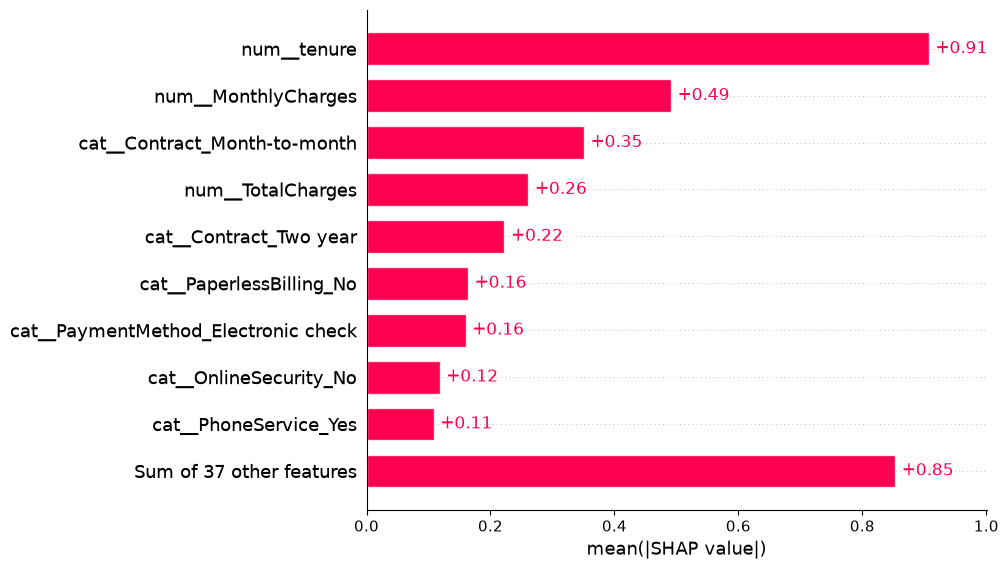

In [104]:
#Graphique Top 10
shap.plots.bar(
    shap_values,
    max_display=10
)

### 15.4. Interprétation de l'importance globale des variables

Le graphique présente les dix variables ayant la plus forte contribution moyenne
aux prédictions de la régression logistique, mesurée à l'aide des valeurs SHAP.

La variable **`tenure`** apparaît comme la plus influente. L'ancienneté du
client joue donc un rôle majeur dans la prédiction du churn. Les clients ayant
une faible ancienneté présentent généralement un risque de résiliation plus
élevé que les clients fidèles depuis plusieurs années.

La deuxième variable la plus importante est **`MonthlyCharges`**. Le montant des
charges mensuelles influence fortement la probabilité de résiliation, les
clients soumis à des factures plus élevées étant généralement plus susceptibles
de quitter l'opérateur.

Le type de contrat constitue également un facteur déterminant. La variable
**`Contract_Month-to-month`** figure parmi les variables les plus importantes,
confirmant que les contrats mensuels sont davantage associés au churn. À
l'inverse, **`Contract_Two year`** contribue à diminuer le risque de
résiliation, ce qui traduit l'effet protecteur des contrats de longue durée.

Les variables **`TotalCharges`**, **`PaperlessBilling`**,
**`PaymentMethod_Electronic check`**, **`OnlineSecurity`** et
**`PhoneService`** présentent également une influence notable, bien que plus
faible que les variables précédentes.

Globalement, les résultats obtenus avec SHAP sont cohérents avec les analyses
exploratoires réalisées dans les missions précédentes. L'ancienneté du client,
le montant de la facture et le type de contrat constituent les principaux
facteurs expliquant la résiliation des abonnés.

## 15.5 Summary Plot

Contrairement au graphique précédent qui présente uniquement l'importance
moyenne des variables, le **Summary Plot** montre également le sens de leur
influence sur les prédictions.

Chaque point représente un client du jeu de test. La couleur indique la valeur
de la variable (faible ou élevée), tandis que la position horizontale
correspond à sa contribution à la prédiction du churn.

Ce graphique permet de comprendre simultanément l'importance des variables et
la manière dont elles influencent les décisions du modèle.

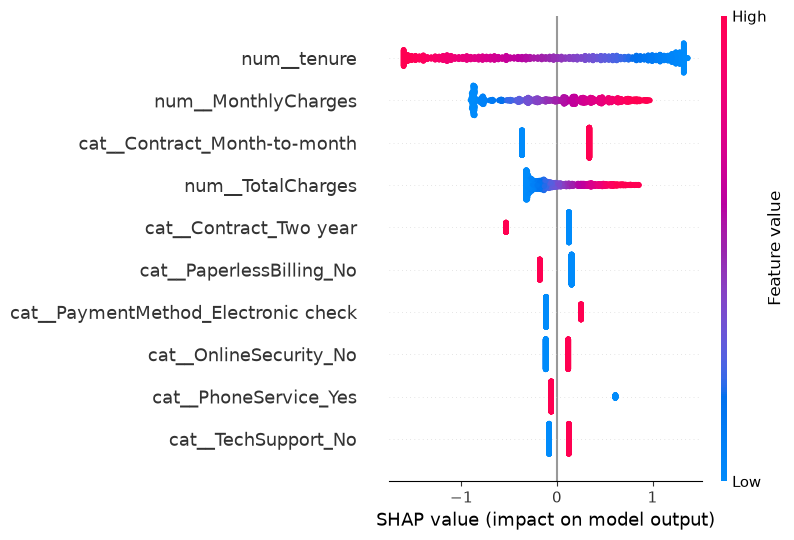

In [107]:
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=feature_names,
    max_display=10
)

### 15.5. Interprétation du Summary Plot

Le **Summary Plot** présente l'impact de chaque variable sur les prédictions du
modèle ainsi que la distribution des valeurs SHAP pour l'ensemble des clients
du jeu de test.

La variable **`tenure`** est celle qui influence le plus les prédictions.
Les clients ayant une **faible ancienneté** (points bleus) présentent
majoritairement des valeurs SHAP positives, ce qui augmente la probabilité de
churn. À l'inverse, une **ancienneté élevée** (points rouges) produit des
valeurs SHAP négatives et réduit le risque de résiliation. Ce résultat confirme
que les clients fidèles sont beaucoup moins susceptibles de quitter
l'opérateur.

La variable **`MonthlyCharges`** est la deuxième plus importante. Les **charges
mensuelles élevées** (points rouges) augmentent généralement le risque de
churn, tandis que des charges faibles (points bleus) diminuent cette
probabilité.

La présence d'un **contrat mensuel** (`Contract_Month-to-month`) contribue
positivement aux valeurs SHAP, ce qui signifie qu'elle augmente le risque de
résiliation. À l'inverse, un **contrat de deux ans**
(`Contract_Two year`) produit principalement des valeurs SHAP négatives,
traduisant un effet protecteur contre le churn.

Les variables **`TotalCharges`**, **`PaperlessBilling`**,
**`PaymentMethod_Electronic check`**, **`OnlineSecurity_No`**,
**`PhoneService_Yes`** et **`TechSupport_No`** présentent également une
influence sur les prédictions, mais leur impact est plus faible que celui des
trois premières variables.

Dans l'ensemble, le Summary Plot confirme les résultats obtenus lors de
l'analyse exploratoire et de l'étude de l'importance globale des variables :
l'ancienneté du client, le montant des charges mensuelles et le type de contrat
sont les principaux facteurs expliquant la résiliation des abonnés.

## 15.6 Explication de décisions individuelles
## 15.6.1 Sélection des observations

Au-delà de l'importance globale des variables, SHAP permet d'expliquer les
raisons ayant conduit le modèle à prendre une décision pour un client
particulier.

Trois observations sont étudiées :

- un **Vrai Positif (VP)** : client ayant réellement résilié et correctement
  identifié par le modèle ;
- un **Vrai Négatif (VN)** : client n'ayant pas résilié et correctement
  identifié ;
- un **Faux Positif (FP)** : client prédit comme résiliant alors qu'il est
  resté fidèle.

In [108]:
#Sélection des indices
# Vrai positif
vp_index = erreurs[
    (erreurs["Churn_reel"]=="Yes") &
    (erreurs["Churn_predit"]=="Yes")
].index[0]

# Vrai négatif
vn_index = erreurs[
    (erreurs["Churn_reel"]=="No") &
    (erreurs["Churn_predit"]=="No")
].index[0]

# Faux positif
fp_index = erreurs[
    (erreurs["Churn_reel"]=="No") &
    (erreurs["Churn_predit"]=="Yes")
].index[0]

print(vp_index, vn_index, fp_index)

3524 437 2280


In [109]:
#Conversion des indices

#Comme SHAP travaille sur X_test_shap, il faut convertir les indices du DataFrame.

vp_pos = X_test.index.get_loc(vp_index)
vn_pos = X_test.index.get_loc(vn_index)
fp_pos = X_test.index.get_loc(fp_index)

print(vp_pos, vn_pos, fp_pos)

13 0 1


In [110]:
#Vérification
print("VP :", erreurs.loc[vp_index, ["Churn_reel","Churn_predit"]])

print("VN :", erreurs.loc[vn_index, ["Churn_reel","Churn_predit"]])

print("FP :", erreurs.loc[fp_index, ["Churn_reel","Churn_predit"]])

VP : Churn_reel      Yes
Churn_predit    Yes
Name: 3524, dtype: str
VN : Churn_reel      No
Churn_predit    No
Name: 437, dtype: str
FP : Churn_reel       No
Churn_predit    Yes
Name: 2280, dtype: str


### 15.6.2 Explication d'un Vrai Positif

Cette observation correspond à un client ayant réellement résilié son
abonnement et correctement identifié par le modèle.

Le graphique SHAP permet d'identifier les variables ayant contribué à cette
prédiction ainsi que leur influence sur la décision finale.

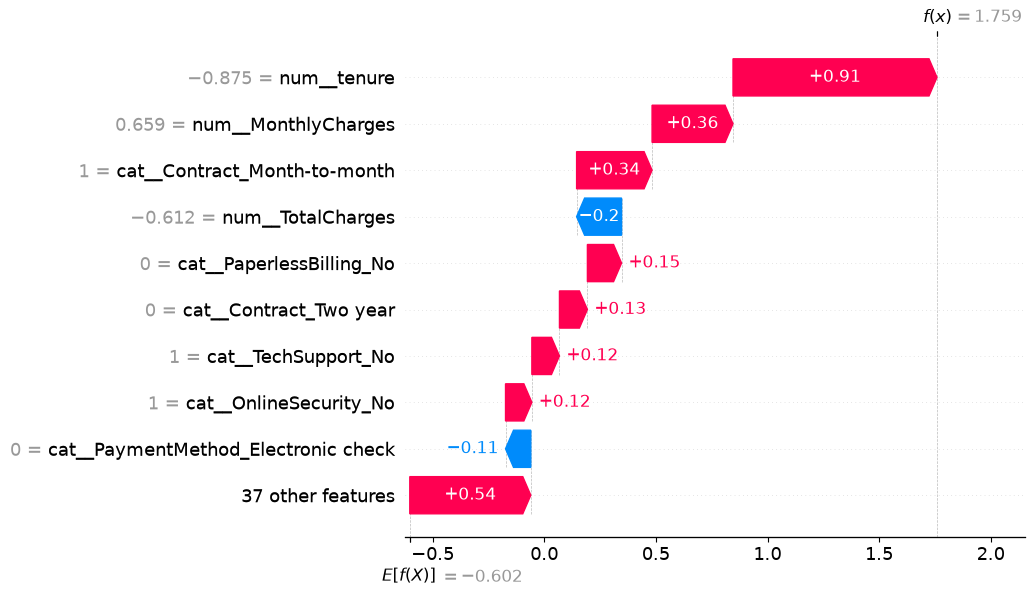

In [111]:
shap.plots.waterfall(
    shap_values[vp_pos],
    max_display=10
)

## Interpretation

Le graphique SHAP montre que plusieurs variables contribuent fortement à la
prédiction de ce client comme étant susceptible de résilier son abonnement.

La variable **`tenure`** constitue le facteur le plus important. La faible
ancienneté du client augmente fortement la probabilité de churn, ce qui est
cohérent avec les analyses précédentes montrant que les nouveaux clients sont
plus susceptibles de quitter l'opérateur.

Les **charges mensuelles élevées** (`MonthlyCharges`) renforcent également le
risque de résiliation. De plus, le fait que le client soit sous un **contrat
mensuel** (`Contract_Month-to-month`) contribue significativement à augmenter
la probabilité de churn.

L'absence de **support technique** (`TechSupport_No`) et de **sécurité en
ligne** (`OnlineSecurity_No`) augmente également le risque de résiliation,
tandis que les variables **`TotalCharges`** et **`PaymentMethod_Electronic check`**
exercent une légère influence négative sur cette probabilité.

Au final, les contributions positives sont largement supérieures aux
contributions négatives, ce qui conduit le modèle à prédire un churn avec une
forte confiance. Cette prédiction est conforme à la réalité, puisqu'il s'agit
d'un **Vrai Positif**.

### 15.6.3 Explication d'un Vrai Négatif

Cette observation correspond à un client n'ayant pas résilié son abonnement et
correctement classé par le modèle.

Les contributions SHAP mettent en évidence les variables ayant réduit la
probabilité de churn.

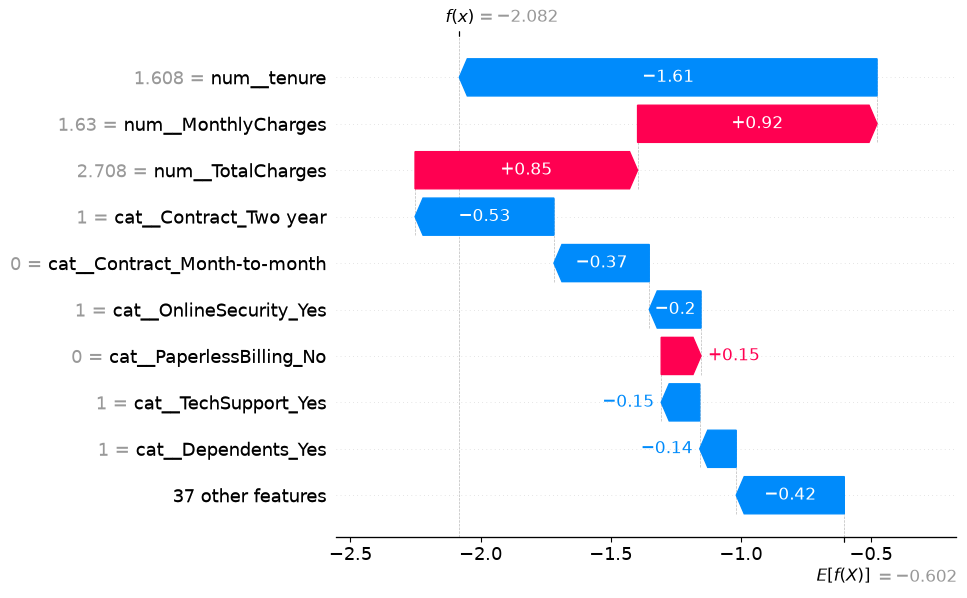

In [112]:
shap.plots.waterfall(
    shap_values[vn_pos],
    max_display=10
)

## interpretation

Le graphique SHAP montre que plusieurs variables contribuent à diminuer la
probabilité de churn de ce client.

La variable **`tenure`** est le facteur le plus influent. La forte ancienneté
du client réduit considérablement le risque de résiliation, ce qui confirme que
les clients fidèles sont généralement moins susceptibles de quitter
l'opérateur.

Les variables **`Contract_Two year`** et l'absence de **contrat mensuel**
(`Contract_Month-to-month`) renforcent également cette prédiction. Un contrat
de longue durée constitue un facteur de fidélisation important et diminue le
risque de churn.

La présence des services **`OnlineSecurity_Yes`** et
**`TechSupport_Yes`** contribue aussi à réduire la probabilité de résiliation,
de même que le fait que le client ait des personnes à charge
(`Dependents_Yes`).

À l'inverse, les **charges mensuelles élevées** (`MonthlyCharges`) et les
**charges totales** (`TotalCharges`) exercent une influence positive sur le
risque de churn. Toutefois, leur effet est largement compensé par la forte
ancienneté du client et par son contrat de deux ans.

Au final, les contributions négatives dominent les contributions positives, ce
qui conduit le modèle à prédire que ce client ne résiliera pas son abonnement.
Cette prédiction est correcte puisqu'il s'agit d'un **Vrai Négatif**.

### 15.6.4 Explication d'un Faux Positif

Cette observation correspond à un client prédit comme susceptible de résilier
alors qu'il est en réalité resté fidèle.

L'analyse SHAP permet de comprendre pourquoi le modèle a attribué une forte
probabilité de churn à ce client malgré son comportement réel.

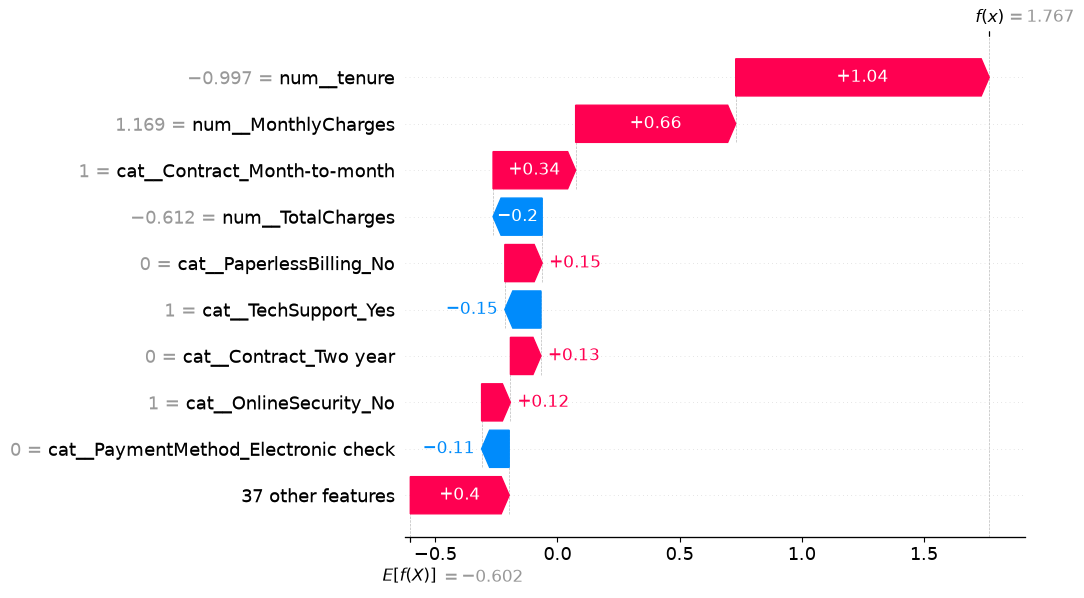

In [113]:
shap.plots.waterfall(
    shap_values[fp_pos],
    max_display=10
)

## interpretation
Le graphique SHAP montre que plusieurs variables poussent fortement le modèle à
prédire un churn, alors que ce client est finalement resté fidèle. Il s'agit
donc d'un **Faux Positif**.

La principale contribution provient de **`tenure`**. La faible ancienneté du
client augmente fortement la probabilité de résiliation. Cette variable est
d'ailleurs la plus influente dans le modèle et constitue le principal facteur
ayant conduit à cette prédiction.

Les **charges mensuelles élevées** (`MonthlyCharges`) renforcent également le
risque de churn. De plus, le client est sous un **contrat mensuel**
(`Contract_Month-to-month`), un profil généralement associé à un risque élevé
de résiliation.

L'absence d'un **contrat de deux ans** (`Contract_Two year`) ainsi que
l'absence de **sécurité en ligne** (`OnlineSecurity_No`) contribuent également
à augmenter la probabilité de churn.

À l'inverse, certaines variables réduisent légèrement ce risque, notamment
**`TotalCharges`**, la présence du **support technique**
(`TechSupport_Yes`) et le mode de paiement
(`PaymentMethod_Electronic check`). Cependant, leurs contributions restent
insuffisantes pour compenser les facteurs de risque dominants.

Ce cas illustre une limite du modèle : bien que ce client présente un profil
très proche de celui des clients ayant effectivement résilié (faible
ancienneté, charges élevées et contrat mensuel), il est finalement resté fidèle.
Cette erreur suggère que d'autres facteurs, non présents dans le jeu de
données, peuvent influencer la décision réelle du client.

## 15.6.7 Dependence Plot de la variable dominante

Le **Dependence Plot** permet d'étudier plus précisément l'effet de la variable
la plus importante sur les prédictions du modèle.

Contrairement au Summary Plot, qui présente simultanément toutes les variables,
ce graphique met en évidence la relation entre les valeurs d'une variable et sa
contribution SHAP. Il permet ainsi de visualiser comment cette variable
influence le risque de churn.

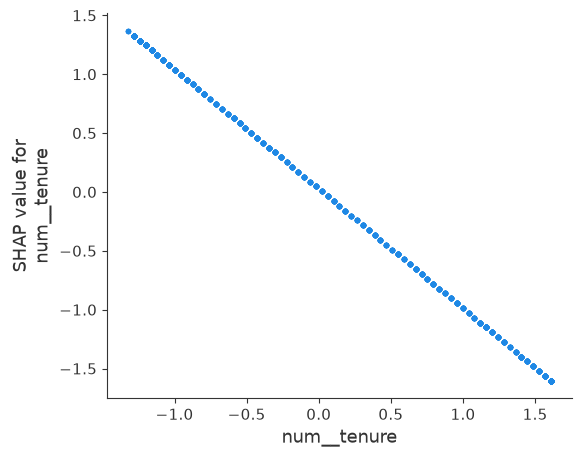

In [122]:
shap.dependence_plot(
    "num__tenure",
    shap_values.values,
    X_test_shap,
    interaction_index=None
)

###  Interprétation du Dependence Plot

Le **Dependence Plot** met en évidence l'effet de la variable **`tenure`**,
identifiée comme la variable la plus importante par l'analyse SHAP.

Le graphique montre une **relation linéaire décroissante** entre l'ancienneté
du client et sa contribution à la prédiction du churn. Lorsque la valeur de
**`tenure`** augmente, la valeur SHAP diminue progressivement.

Les valeurs SHAP positives, observées pour les faibles niveaux d'ancienneté,
augmentent la probabilité de churn. À l'inverse, les valeurs SHAP négatives,
associées aux clients ayant une ancienneté plus élevée, réduisent la
probabilité de résiliation.

Cette relation confirme que les nouveaux clients présentent un risque plus
important de quitter l'opérateur, tandis que les clients fidèles sont beaucoup
moins susceptibles de résilier leur abonnement.

L'absence de rupture ou de changement brutal dans la courbe s'explique par la
nature linéaire de la régression logistique. Contrairement à des modèles plus
complexes comme Random Forest ou XGBoost, l'effet de **`tenure`** est ici
presque proportionnel sur toute la plage des valeurs observées.

Ce graphique confirme ainsi les résultats obtenus avec le Top 10 des variables,
le Summary Plot et les explications individuelles : **l'ancienneté du client
constitue le principal facteur expliquant la probabilité de churn dans ce
modèle.**

# 16. Choix du seuil de décision

## 16.1 Principe

Par défaut, un modèle de classification prédit un churn lorsque la probabilité
estimée est supérieure ou égale à **0,5**.

Cependant, ce seuil n'est pas toujours optimal d'un point de vue métier. Dans
un problème de prédiction du churn, les coûts associés aux erreurs de
classification sont généralement différents.

Dans cette étude, l'objectif est de déterminer le seuil de décision permettant
de maximiser la performance du modèle tout en tenant compte du coût des erreurs
défini dans la Mission 0.

## 16.2 Probabilités du modèle calibré

Nous allons utiliser le modèle calibré, car ses probabilités sont plus fiables.

In [114]:
# Probabilités de churn du modèle calibré
y_proba = calibrated_pipeline.predict_proba(X_test)[:, 1]

## 16.3 Tester plusieurs seuils

In [115]:
thresholds = np.arange(0.10, 0.91, 0.05)

In [118]:
#Calcul des métriques
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for t in thresholds:

    y_pred = np.where(y_proba >= t, "Yes", "No")

    results.append({

        "Threshold": t,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(
            y_test,
            y_pred,
            pos_label="Yes"
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            pos_label="Yes"
        ),

        "F1-score": f1_score(
            y_test,
            y_pred,
            pos_label="Yes"
        )

    })

results = pd.DataFrame(results)

results.round(3)

C:\telco-churn-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

C:\telco-churn-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



,Threshold,Accuracy,Precision,Recall,F1-score
0,0.10,0.610,0.402,0.955,0.565
1,0.15,0.664,0.437,0.914,0.591
2,0.20,0.705,0.470,0.861,0.608
3,0.25,0.732,0.498,0.802,0.614
4,0.30,0.752,0.523,0.751,0.617
5,0.35,0.767,0.546,0.709,0.617
6,0.40,0.776,0.566,0.674,0.615
7,0.45,0.795,0.613,0.615,0.614
8,0.50,0.803,0.651,0.553,0.598
9,0.55,0.800,0.684,0.457,0.548


### 16.3 Interprétation des différents seuils

Les performances du modèle ont été évaluées pour plusieurs seuils de décision
compris entre **0,10** et **0,90**.

Les résultats montrent que le comportement du modèle évolue fortement avec le
choix du seuil.

Pour les seuils faibles (0,10 à 0,20), le modèle détecte presque tous les
clients susceptibles de résilier, ce qui se traduit par un **rappel très élevé**.
En revanche, cette stratégie génère également davantage de faux positifs et une
précision plus faible.

À mesure que le seuil augmente, la précision s'améliore progressivement tandis
que le rappel diminue. Le modèle devient alors plus conservateur et ne prédit
un churn que lorsque la probabilité estimée est très élevée.

Le **F1-score**, qui constitue la métrique retenue dans cette étude, atteint sa
meilleure valeur (**0,617**) pour des seuils de **0,30** et **0,35**.
À l'inverse, le seuil classique de **0,50** conduit à un F1-score inférieur
(**0,598**).

Ces résultats montrent que le seuil par défaut de 0,50 n'est pas le plus
adapté à ce problème de classification. Un seuil compris entre **0,30** et
**0,35** permet d'obtenir un meilleur compromis entre la précision et le
rappel.

## 16.4 Visualisation des performances selon le seuil

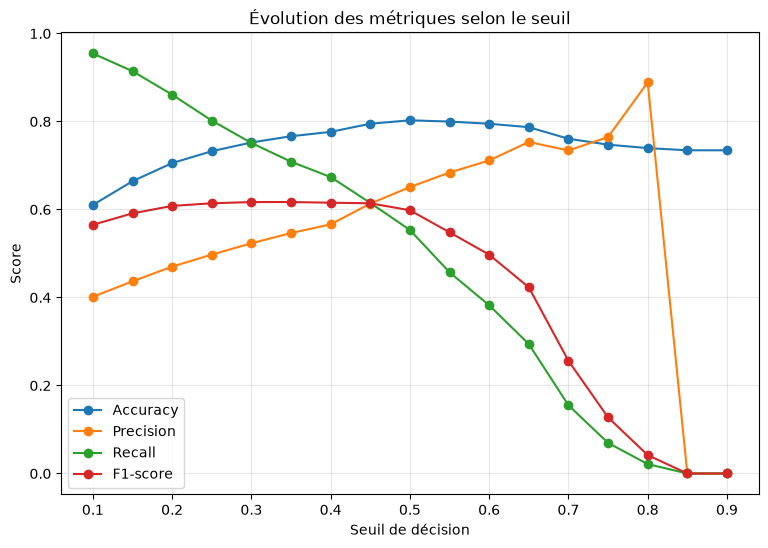

In [119]:
plt.figure(figsize=(9,6))

plt.plot(results["Threshold"], results["Accuracy"], marker="o", label="Accuracy")
plt.plot(results["Threshold"], results["Precision"], marker="o", label="Precision")
plt.plot(results["Threshold"], results["Recall"], marker="o", label="Recall")
plt.plot(results["Threshold"], results["F1-score"], marker="o", label="F1-score")

plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Évolution des métriques selon le seuil")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

### 16.4.1 Interprétation des métriques selon le seuil

Le graphique montre l'évolution des principales métriques de performance
(Accuracy, Precision, Recall et F1-score) en fonction du seuil de décision.

On observe que lorsque le seuil augmente, la **précision** progresse
progressivement. En effet, le modèle devient plus exigeant avant de prédire un
churn et commet donc moins de faux positifs. À l'inverse, le **rappel** diminue
fortement, car un nombre croissant de clients qui résilieront effectivement ne
sont plus détectés.

L'**accuracy** reste relativement stable entre les seuils **0,30** et **0,60**,
avec une valeur maximale proche de **0,80** autour du seuil **0,50**. Cependant,
cette métrique est moins adaptée à un problème de classes déséquilibrées comme
la prédiction du churn.

Le **F1-score**, qui combine la précision et le rappel, atteint sa valeur
maximale (**0,617**) pour des seuils compris entre **0,30** et **0,35**. Cette
zone représente donc le meilleur compromis entre la capacité à détecter les
clients susceptibles de résilier et la limitation des fausses alertes.

À partir d'un seuil supérieur à **0,60**, le rappel diminue rapidement, ce qui
dégrade fortement le F1-score. Le modèle devient alors trop conservateur et ne
détecte plus suffisamment de clients à risque.

Ces résultats montrent que le seuil par défaut de **0,50** n'est pas
nécessairement le meilleur choix lorsque l'objectif est de maximiser les
performances globales du modèle.

## 16.5 Choix du seuil selon le coût métier

In [120]:
from sklearn.metrics import confusion_matrix

couts = []

for t in thresholds:

    y_pred = np.where(y_proba >= t, "Yes", "No")

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=["No", "Yes"]
    ).ravel()

    cout = fp * 50 + fn * 300

    couts.append({
        "Threshold": t,
        "FP": fp,
        "FN": fn,
        "Coût total": cout
    })

couts = pd.DataFrame(couts)

couts

,Threshold,FP,FN,Coût total
0,0.10,532,17,31700
1,0.15,441,32,31650
2,0.20,363,52,33750
3,0.25,303,74,37350
4,0.30,256,93,40700
5,0.35,220,109,43700
6,0.40,193,122,46250
7,0.45,145,144,50450
8,0.50,111,167,55650
9,0.55,79,203,64850


In [121]:
couts.sort_values("Coût total").head()

,Threshold,FP,FN,Coût total
1,0.15,441,32,31650
0,0.10,532,17,31700
2,0.20,363,52,33750
3,0.25,303,74,37350
4,0.30,256,93,40700


### 16.5.1 Interprétation du coût métier

Le tableau présente l'évolution du coût total des erreurs de classification en
fonction du seuil de décision, en considérant qu'un **faux négatif** coûte
**300 unités** et qu'un **faux positif** coûte **50 unités**.

Les résultats montrent que le **coût total minimal est obtenu pour un seuil de
0,15**, avec un coût de **31 650**. Ce seuil génère **441 faux positifs** mais
seulement **32 faux négatifs**.

Lorsque le seuil augmente, le nombre de faux positifs diminue progressivement.
En revanche, le nombre de faux négatifs augmente fortement. Comme le coût d'un
faux négatif est six fois supérieur à celui d'un faux positif, cette
augmentation entraîne une hausse importante du coût total.

Par exemple, au seuil de **0,50**, le modèle ne produit plus que **111 faux
positifs**, mais le nombre de faux négatifs atteint **167**, ce qui conduit à
un coût total de **55 650**, soit près du double de celui obtenu avec le seuil
de **0,15**.

Ces résultats montrent que, dans un contexte où il est beaucoup plus coûteux de
ne pas détecter un client susceptible de résilier que de contacter inutilement
un client fidèle, il est préférable d'adopter un seuil plus faible.

Ainsi, le **seuil de 0,15** constitue le meilleur choix d'un point de vue
économique, car il minimise le coût global des erreurs de classification.

## 16.6 Conclusion sur le choix du seuil

L'analyse des différents seuils de décision montre que le seuil par défaut de
**0,50** n'est pas le plus adapté à la prédiction du churn.

Du point de vue des performances statistiques, le **F1-score** est maximal
(**0,617**) pour un seuil compris entre **0,30** et **0,35**. Cette plage
offre le meilleur compromis entre la précision et le rappel et constitue le
choix le plus pertinent lorsque l'objectif est d'obtenir un modèle équilibré.

En revanche, lorsque les coûts métier sont pris en compte, le résultat est
différent. En considérant qu'un faux négatif coûte **300 unités** contre
**50 unités** pour un faux positif, le coût total minimal (**31 650**) est
obtenu avec un **seuil de 0,15**. Ce seuil permet de réduire fortement le
nombre de clients réellement susceptibles de résilier qui ne seraient pas
détectés.

Ainsi, le choix du seuil dépend directement de l'objectif poursuivi :

- un **seuil de 0,30** est recommandé si l'on cherche à maximiser les
  performances globales du modèle à l'aide du F1-score ;
- un **seuil de 0,15** est préférable dans un contexte opérationnel où le coût
  lié à la perte d'un client est nettement supérieur à celui d'une action de
  fidélisation menée auprès d'un client qui ne résiliera finalement pas.

Cette analyse montre qu'un seuil de décision ne doit pas être fixé
arbitrairement à **0,50**, mais qu'il doit être adapté aux contraintes
économiques et aux objectifs métier de l'entreprise.

# 17. Sauvegarde du modèle final

À l'issue de l'optimisation, de la calibration et de l'analyse
d'interprétabilité, le modèle final est sauvegardé afin de pouvoir être
réutilisé ultérieurement sans devoir être réentraîné.

Le pipeline sauvegardé comprend le prétraitement des données, la régression
logistique optimisée ainsi que l'étape de calibration des probabilités.

In [123]:
import joblib

joblib.dump(
    calibrated_pipeline,
    "../model/modele_final_calibre.joblib"
)

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


In [125]:
#Vérification
modele = joblib.load("../model/modele_final_calibre.joblib")

modele

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...1156699764))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00235E4C245F0>, <sk

In [126]:
#les meilleurs hyperparamètres :
joblib.dump(
    study.best_params,
    "../model/meilleurs_hyperparametres.joblib"
)

['../model/meilleurs_hyperparametres.joblib']

In [127]:
#1. Vérifier que le fichier existe
import os

os.path.exists("../model/meilleurs_hyperparametres.joblib")

True

In [128]:
#2. Charger le fichier
import joblib

params = joblib.load("../model/meilleurs_hyperparametres.joblib")

params

{'solver': 'saga',
 'penalty': 'elasticnet',
 'C': 0.1813191635347958,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'tol': 0.0005015471156699764,
 'max_iter': 1284,
 'l1_ratio': 0.9121791321244991}

# 18. Sérialisation du pipeline final

## 18.1 Export du pipeline

À l'issue de la Mission 4, le pipeline final optimisé et calibré a été
sérialisé avec la bibliothèque **joblib** afin de pouvoir être réutilisé sans
réentraîner le modèle.

Le pipeline est enregistré dans le fichier :

- `model/modele_final_calibre.joblib`

Ce fichier contient l'ensemble du pipeline de prédiction, incluant le
prétraitement des données, la régression logistique optimisée ainsi que la
calibration des probabilités.

---

## 18.2 Vérification après rechargement

Afin de vérifier que la sérialisation n'altère pas le comportement du modèle,
le pipeline sauvegardé a été rechargé avec `joblib.load()` puis utilisé pour
effectuer une prédiction sur un client de test.

Le résultat obtenu est le suivant :

- **Prédiction :** `Yes`
- **Probabilité de churn :** `0,7429`

Le même client a ensuite été soumis à l'endpoint **POST `/predict`** de
l'API FastAPI. La réponse obtenue est identique :

```json
{
    "prediction": "Yes",
    "probability": 0.7429
}
```

Les prédictions et les probabilités sont donc strictement identiques après le
rechargement du pipeline.

Cette vérification confirme que la sérialisation avec **joblib** préserve
intégralement le comportement du modèle et garantit que le pipeline utilisé par
l'API est exactement celui qui a été validé lors de la Mission 4.

# 19. Monitoring du modèle

## 19.1 Pourquoi mettre en place un monitoring ?

Une fois déployé, un modèle de Machine Learning n'est pas figé. Les données
qu'il reçoit peuvent évoluer au fil du temps, ce qui peut entraîner une baisse
de ses performances.

Le monitoring consiste à surveiller en continu le comportement du modèle afin
de détecter rapidement toute dégradation et de décider s'il est nécessaire de
le réentraîner.

---

## 19.2 Data Drift

Le **Data Drift** correspond à une modification de la distribution des données
d'entrée entre la phase d'entraînement et la phase de production.

Par exemple :

- augmentation du nombre de clients utilisant la fibre optique ;
- évolution des méthodes de paiement ;
- variation des montants des factures mensuelles.

Lorsque ces distributions deviennent différentes de celles observées pendant
l'entraînement, les prédictions du modèle peuvent devenir moins fiables.

Les principaux indicateurs pouvant être surveillés sont :

- la distribution des variables numériques ;
- la fréquence des variables catégorielles ;
- le taux de valeurs manquantes ;
- les statistiques descriptives (moyenne, médiane, écart-type).

---

## 19.3 Concept Drift

Le **Concept Drift** apparaît lorsque la relation entre les variables
explicatives et la variable cible évolue au fil du temps.

Autrement dit, le comportement des clients change.

Par exemple :

- une nouvelle politique commerciale réduit le taux de résiliation ;
- une nouvelle offre fidélise davantage les clients ;
- les habitudes des utilisateurs évoluent.

Dans ce cas, même si les données semblent similaires, les prédictions peuvent
devenir moins pertinentes.

Le Concept Drift nécessite généralement un réentraînement du modèle avec des
données plus récentes.

---

## 19.4 Performance Drift

Le **Performance Drift** correspond à une diminution progressive des
performances du modèle en production.

Les métriques pouvant être surveillées sont notamment :

- Accuracy ;
- Precision ;
- Recall ;
- F1-score ;
- ROC-AUC.

Une baisse significative de ces indicateurs peut indiquer que le modèle doit
être mis à jour.

---

## 19.5 Outils de monitoring

Deux outils open-source sont particulièrement adaptés au suivi des modèles de
Machine Learning.

### Evidently AI

Evidently AI permet de :

- détecter le Data Drift ;
- surveiller les performances du modèle ;
- comparer les données d'entraînement et les données de production ;
- générer des rapports interactifs.

Cet outil est particulièrement adapté aux modèles de classification comme la
prédiction du churn.

### WhyLogs

WhyLogs est une bibliothèque dédiée au profilage et au suivi des données.

Elle permet notamment de :

- détecter les anomalies ;
- suivre l'évolution des variables ;
- surveiller la qualité des données ;
- conserver des statistiques sur les données de production.

---

## 19.6 Plan de monitoring proposé

Pour ce projet, le plan de surveillance recommandé est le suivant :

| Élément surveillé | Fréquence | Outil recommandé |
|-------------------|-----------|------------------|
| Distribution des variables | Quotidienne | Evidently AI |
| Valeurs manquantes | Quotidienne | WhyLogs |
| Data Drift | Hebdomadaire | Evidently AI |
| Performance du modèle | Hebdomadaire | Evidently AI |
| Concept Drift | Mensuelle | Analyse métier + réentraînement |

---

## 19.7 Conclusion

Le monitoring constitue une étape essentielle du cycle de vie d'un modèle de
Machine Learning.

Même si le modèle présente de bonnes performances lors de son entraînement,
ses résultats peuvent évoluer avec le temps en raison des changements dans les
données ou dans le comportement des clients.

La surveillance régulière des données, des performances et des différents types
de drift, associée à des outils tels qu'**Evidently AI** et **WhyLogs**, permet
de maintenir un modèle fiable, performant et adapté aux nouvelles données de
production.